<a href="https://colab.research.google.com/github/prathik-codoc/Machine-Learning-Projects/blob/main/7.%20Car%20Price%20Prediction/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learing:
## Regression Model:
Linear & Lasso Regression Model

Importing Dependencies

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn import metrics

Data Collection and processing

In [29]:
# Loading dataset as Pandas DataFramec
car_data = pd.read_csv('/content/drive/MyDrive/Machine Learning Projects/Car Price Prediction/car data.csv')

In [30]:
# inspecting the first 5 rows of the DataFrame
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [31]:
#Checking the no of datapoints
car_data.shape

(301, 9)

In [32]:
# geting some info abt the dataset
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [33]:
# Checking the number of missing values

car_data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [34]:
# checking the distribution of categorical data
print(car_data.Fuel_Type.value_counts())
print(car_data.Seller_Type.value_counts())
print(car_data.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [35]:
# Encoding 'Fuel Type' Column
car_data.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}}, inplace=True)
# Encoding 'Seller Type' Column
car_data.replace({'Seller_Type':{'Dealer':0,'Individual':1}}, inplace=True)
# Encoding 'Transmission' Column
car_data.replace({'Transmission':{'Manual':0,'Automatic':1}}, inplace=True)

/tmp/ipykernel_3703/3776017821.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_data.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}}, inplace=True)
/tmp/ipykernel_3703/3776017821.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_data.replace({'Seller_Type':{'Dealer':0,'Individual':1}}, inplace=True)
/tmp/ipykernel_3703/3776017821.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=Fals

In [36]:
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


Splitting the data into Training and test data

In [37]:
X = car_data.drop(['Car_Name','Selling_Price'], axis=1)
Y = car_data['Selling_Price']

In [38]:
# Splitting the data into training and testing
X_train,X_test,Y_train,Y_test = train_test_split(X, Y, test_size = 0.1, random_state=2)

Model Training

1. Linear Regression

In [39]:
# Loading the linear regression model
lin_reg_model = LinearRegression()

In [40]:
lin_reg_model.fit(X_train,Y_train)

LinearRegression()

Model Evaluation

In [41]:
# Prediction on training data
training_data_prediction = lin_reg_model.predict(X_train)

Accuracy Score is used in case of Classification

R Squared error is used in case of Regression model

In [42]:
# R Squared error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R Squared error ", error_score)

R Squared error  0.8799451660493711


Visualize the actual prices and predicted prices

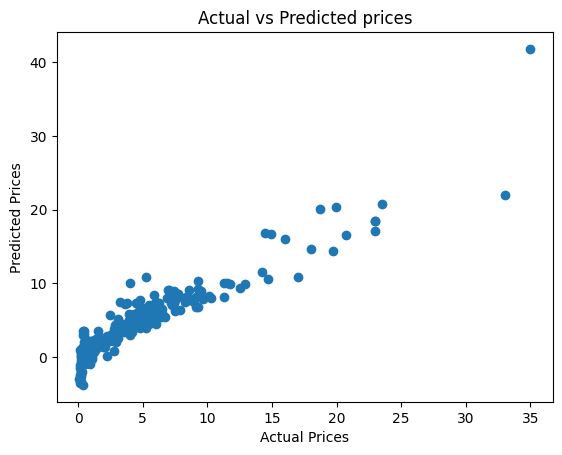

In [43]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted prices")
plt.show()

In [44]:
# Prediciton using test data
test_data_prediction = lin_reg_model.predict(X_test)

In [45]:
# R Squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R Squared Error ", error_score)

R Squared Error  0.8365766715027051


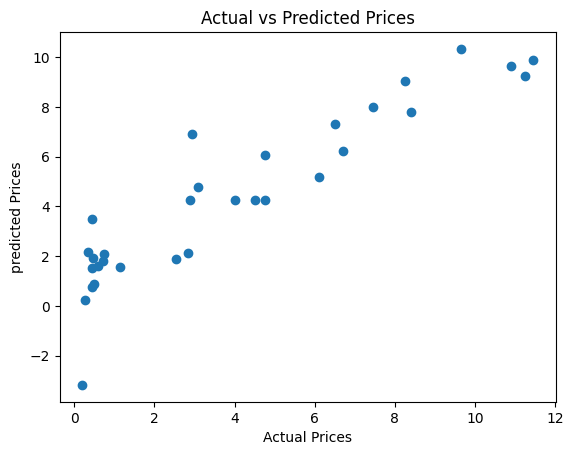

In [46]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

2. Lasso Regression

In [47]:
#Loading the laso Regression model
las_reg_model = Lasso()

In [48]:
las_reg_model.fit(X_train, Y_train)

Lasso()

Model Evaluation

In [51]:
# Prediction on training data
training_data_prediction = las_reg_model.predict(X_train)

In [52]:
# R Squared Value
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R Squared Error ", error_score)

R Squared Error  0.8427856123435794


Visualization of actual vs predicted prices

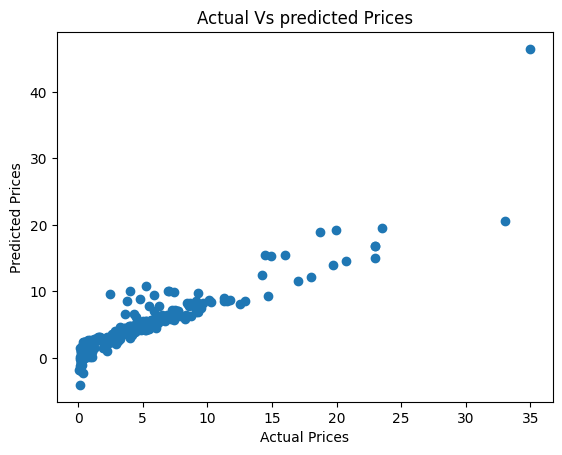

In [53]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Vs predicted Prices")
plt.show()

In [55]:
# Prediction using test data
test_data_prediction = las_reg_model.predict(X_test)

In [57]:
# R Squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R Squared Error ", error_score)

R Squared Error  0.8709167941173195


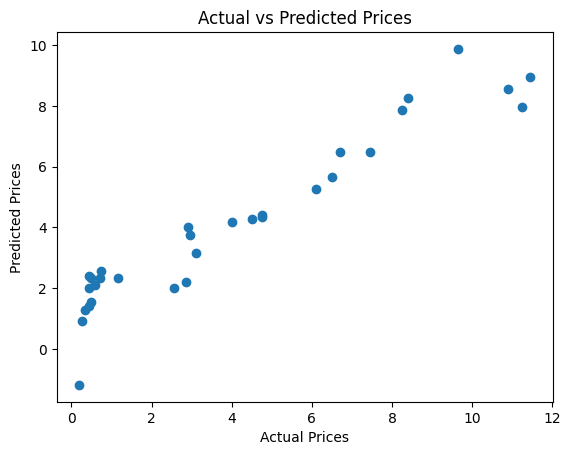

In [58]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()